In [5]:
import os
import numpy as np
from dotenv import load_dotenv
import matplotlib.pyplot as plt
from astropy.table import Table
from astropy.wcs import WCS
from astropy.io import fits
load_dotenv("/home/yacheng/nexus/ssl_outthere/.env")

if not os.path.exists("spectra-fitting.fits"):
    !wget --user="$OUTTHERE_USER" --password="$OUTTHERE_PASSWORD" \
        https://outthere-mpia.org/s3/data/spectra-fitting.fits

if not os.path.exists("phomoetry.fits"):
    !wget --user="$OUTTHERE_USER" --password="$OUTTHERE_PASSWORD" \
        https://outthere-mpia.org/s3/data/phomoetry.fits



In [6]:
fields = [
    "aqr-00", "aqr-01", "aqr-02",
    "boo-00", "boo-01", "boo-02", "boo-03", "boo-04", "boo-05", "boo-06",
    "boo-07", "boo-08", "boo-09", "boo-10", "boo-11",
    "cam-00",
    "cet-00", "cet-01", "cet-02", "cet-03", "cet-04", "cet-05", "cet-06",
    "cet-07", "cet-08", "cet-09", "cet-10",
    "col-00",
    "com-00", "com-01", "com-02",
    "crb-00",
    "crt-00", "crt-01",
    "crv-00",
    "cvn-00",
    "dor-00", "dor-01", "dor-02", "dor-03",
    "dra-00", "dra-01", "dra-02",
    "eri-00",
    "gru-00",
    "her-00", "her-01",
    "hya-00", "hya-01", "hya-02",
    "leo-00", "leo-01", "leo-02", "leo-03", "leo-04", "leo-05", "leo-06",
    "leo-07", "leo-08", "leo-09", "leo-10", "leo-11", "leo-12", "leo-13",
    "leo-14", "leo-15", "leo-16", "leo-17",
    "lib-00", "lib-01", "lib-02", "lib-03",
    "lmi-00", "lmi-01",
    "lyn-00",
    "psc-00",
    "sex-00", "sex-01", "sex-02", "sex-03", "sex-04", "sex-05", "sex-06",
    "sex-07", "sex-08", "sex-09", "sex-10", "sex-11", "sex-12", "sex-13",
    "sex-14", "sex-15", "sex-16", "sex-17", "sex-18", "sex-19", "sex-20",
    "sex-21", "sex-22", "sex-23", "sex-24", "sex-25", "sex-26", "sex-27",
    "sex-28", "sex-29", "sex-30", "sex-31", "sex-32", "sex-33", "sex-34",
    "sgr-00",
    "tri-00", "tri-01", "tri-02", #"tri-03",
    "uma-00", "uma-01", "uma-02", "uma-03", "uma-04", "uma-05", "uma-06",
    "uma-07", "uma-08", "uma-09", "uma-10", "uma-11",
    "vir-00", "vir-01", "vir-02", "vir-03", "vir-04", "vir-05", "vir-06",
    "vir-07", "vir-08", "vir-09", "vir-10", "vir-11", "vir-12", "vir-13",
    "vir-14", "vir-15", "vir-16",
]

filters = ['f115wn', 'f150wn', 'f200wn']

print(len(fields), "fields")

detection = Table.read(f"imaging/{fields[0]}/{fields[0]}-ir.cat.fits")
print(detection.colnames)
detection[:5]

144 fields
['THRESH', 'NPIX', 'TNPIX', 'XMIN', 'XMAX', 'YMIN', 'YMAX', 'X', 'Y', 'X2_IMAGE', 'Y2_IMAGE', 'XY_IMAGE', 'ERRX2', 'ERRY2', 'ERRXY', 'A_IMAGE', 'B_IMAGE', 'THETA_IMAGE', 'CXX_IMAGE', 'CYY_IMAGE', 'CXY_IMAGE', 'CFLUX', 'FLUX', 'CPEAK', 'PEAK', 'XCPEAK', 'YCPEAK', 'XPEAK', 'YPEAK', 'FLAG', 'X_IMAGE', 'Y_IMAGE', 'NUMBER', 'RA', 'DEC', 'X_WORLD', 'Y_WORLD', 'FLUX_ISO', 'FLUXERR_ISO', 'AREA_ISO', 'MAG_ISO', 'KRON_RADIUS', 'KRON_RCIRC', 'FLUX_AUTO', 'FLUXERR_AUTO', 'BKG_AUTO', 'FLAG_AUTO', 'AREA_AUTO', 'FLUX_RADIUS_FLAG', 'FLUX_RADIUS_20', 'FLUX_RADIUS', 'FLUX_RADIUS_90', 'TOT_CORR', 'MAG_AUTO', 'MAGERR_AUTO', 'FLUX_APER_0', 'FLUXERR_APER_0', 'FLAG_APER_0', 'BKG_APER_0', 'MASK_APER_0', 'FLUX_APER_1', 'FLUXERR_APER_1', 'FLAG_APER_1', 'BKG_APER_1', 'MASK_APER_1', 'FLUX_APER_2', 'FLUXERR_APER_2', 'FLAG_APER_2', 'BKG_APER_2', 'MASK_APER_2', 'FLUX_APER_3', 'FLUXERR_APER_3', 'FLAG_APER_3', 'BKG_APER_3', 'MASK_APER_3', 'FLUX_APER_4', 'FLUXERR_APER_4', 'FLAG_APER_4', 'BKG_APER_4', 'MASK_A

THRESH,NPIX,TNPIX,XMIN,XMAX,YMIN,YMAX,X,Y,X2_IMAGE,Y2_IMAGE,XY_IMAGE,ERRX2,ERRY2,ERRXY,A_IMAGE,B_IMAGE,THETA_IMAGE,CXX_IMAGE,CYY_IMAGE,CXY_IMAGE,CFLUX,FLUX,CPEAK,PEAK,XCPEAK,YCPEAK,XPEAK,YPEAK,FLAG,X_IMAGE,Y_IMAGE,NUMBER,RA,DEC,X_WORLD,Y_WORLD,FLUX_ISO,FLUXERR_ISO,AREA_ISO,MAG_ISO,KRON_RADIUS,KRON_RCIRC,FLUX_AUTO,FLUXERR_AUTO,BKG_AUTO,FLAG_AUTO,AREA_AUTO,FLUX_RADIUS_FLAG,FLUX_RADIUS_20,FLUX_RADIUS,FLUX_RADIUS_90,TOT_CORR,MAG_AUTO,MAGERR_AUTO,FLUX_APER_0,FLUXERR_APER_0,FLAG_APER_0,BKG_APER_0,MASK_APER_0,FLUX_APER_1,FLUXERR_APER_1,FLAG_APER_1,BKG_APER_1,MASK_APER_1,FLUX_APER_2,FLUXERR_APER_2,FLAG_APER_2,BKG_APER_2,MASK_APER_2,FLUX_APER_3,FLUXERR_APER_3,FLAG_APER_3,BKG_APER_3,MASK_APER_3,FLUX_APER_4,FLUXERR_APER_4,FLAG_APER_4,BKG_APER_4,MASK_APER_4,FLUX_APER_5,FLUXERR_APER_5,FLAG_APER_5,BKG_APER_5,MASK_APER_5,FLUX_APER_6,FLUXERR_APER_6,FLAG_APER_6,BKG_APER_6,MASK_APER_6
,,,,,,,,,,,,,,,,,,,,,uJy,uJy,uJy,uJy,,,,,,,,,deg,deg,deg,deg,uJy,uJy,,uJy,pix,pix,uJy,uJy,uJy,,,,,,,pix,uJy,uJy,uJy,uJy,,uJy,,uJy,uJy,,uJy,,uJy,uJy,,uJy,,uJy,uJy,,uJy,,uJy,uJy,,uJy,,uJy,uJy,,uJy,,uJy,uJy,,uJy,
float64,int64,int64,int64,int64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,int64,int64,int64,int64,int64,float64,float64,int32,float64,float64,float64,float64,float64,float64,int64,float64,float64,float64,float64,float64,float64,int64,float64,int16,float64,float64,float64,float64,float64,float64,float64,float64,int16,float64,float64,float64,float64,int16,float64,float64,float64,float64,int16,float64,float64,float64,float64,int16,float64,float64,float64,float64,int16,float64,float64,float64,float64,int16,float64,float64,float64,float64,int16,float64,float64
1.8000000270854392e+30,6720,0,331,2570,0,2,1511.109563721498,0.9997371519178593,245337.32030155463,0.6227116285181619,0.3027938179109242,0.0,0.0,0.0,495.31536865234375,0.7891205549240112,1.2341970432316884e-06,4.076023287780117e-06,1.6058807373046875,-3.96393625123892e-06,0.2988289433501332,0.4422011415749202,0.00010634515556404465,0.00013987595895585504,1020,1,1019,0,2,1512.109563721498,1.9997371519178593,1,343.0816671692618,-18.03165973690194,343.0816671692618,-18.03165973690194,0.0,0.0,0,inf,2.4,47.44864573602046,--,--,--,32,7072.899962907339,48,0.0,0.0,0.0,1.0,--,--,--,--,48,--,45.052053700361355,--,--,48,--,79.92473710685876,--,--,48,--,146.3804940411397,--,--,48,--,282.8403126202659,--,--,48,--,398.3462147019755,--,--,48,--,608.4132006905448,--,--,48,--,2321.3826295195067
1.8000000270854392e+30,984,0,2764,3091,0,2,2901.394465807866,0.9988500139963361,6522.045478007894,0.6227103312306366,0.09298120571381219,0.0,0.0,0.0,80.75918579101562,0.7891191244125366,1.4257810107665136e-05,0.00015332645853050053,1.6058865785598755,-4.578847801894881e-05,0.0526879206322528,0.07797573725210578,0.00011623867168310446,0.00015347275852452505,2842,1,2842,0,2,2902.394465807866,1.998850013996336,2,343.0654216733606,-18.031659835255315,343.0654216733606,-18.031659835255315,0.0,0.0,0,inf,2.4,19.1592494519731,--,--,--,32,1153.2059024738649,48,0.0,0.0,0.0,1.0,--,--,--,--,48,--,45.044525642476,--,--,48,--,79.91397165620722,--,--,48,--,146.36519872723804,--,--,48,--,282.81829428016846,--,--,48,--,398.3197338434331,--,--,48,--,608.3800395453499,--,--,48,--,2321.3161473748182
0.08030219376087189,32,31,3240,3246,189,195,3242.7144640662773,192.29891353827327,2.1185560856846894,2.18399240548813,0.1621736176388353,0.007522320025318878,0.007430276906273009,0.0006782485249987483,1.5220760107040405,1.409195899963379,0.8849359154701233,0.47471800446510315,0.46049460768699646,-0.0705009177327156,0.046466293118505635,0.05629970832799042,0.002238080167262739,0.003941484488658193,3243,192,3243,192,0,3243.7144640662773,193.29891353827327,3,343.0614334783953,-18.029534093858814,343.0614334783953,-18.029534093858814,0.052557664690012065,0.0024017757402181104,28,27.098409850381216,3.8,5.565285551745738,0.09883332309644668,0.014464349

In [4]:
import requests
import concurrent.futures
from tqdm.auto import tqdm

def download_from_url(url, out_path, overwrite=False):
    """Download one url to out_path. Returns 'skipped' or 'downloaded'."""
    if os.path.exists(out_path) and not overwrite:
        return "skipped"
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    r = requests.get(url, auth=(os.environ["OUTTHERE_USER"], os.environ["OUTTHERE_PASSWORD"]))
    r.raise_for_status()
    with open(out_path, "wb") as f:
        f.write(r.content)
    return "downloaded"

def multi_thread_download(jobs, nworkers=20, overwrite=False, desc="download"):
    """jobs: list of (url, out_path). Returns dict with succeeded/skipped/failed stats."""
    stats = {"downloaded": [], "skipped": [], "failed": {}}
    with concurrent.futures.ThreadPoolExecutor(max_workers=nworkers) as executor:
        fut_to_job = {
            executor.submit(download_from_url, url, out_path, overwrite): (url, out_path)
            for url, out_path in jobs
        }
        for fut in tqdm(concurrent.futures.as_completed(fut_to_job),
                        total=len(fut_to_job), desc=desc):
            url, out_path = fut_to_job[fut]
            try:
                status = fut.result()      # 'skipped' or 'downloaded'
                stats[status].append(out_path)
            except Exception as e:
                stats["failed"][url] = repr(e)

    print(f"{desc}: {len(stats['downloaded'])} downloaded, "
          f"{len(stats['skipped'])} skipped, {len(stats['failed'])} failed")
    #if stats["failed"]:
        #for url, err in list(stats["failed"].items())[:10]:
            #print("  FAIL", url, "->", err)
    return stats

# download {field}-ir.cat.fits (detection catalog) for all fields
jobs = [
    (f"https://outthere-mpia.org/s3/data/{field}/{field}-ir.cat.fits",
     f"imaging/{field}/{field}-ir.cat.fits")
    for field in fields
]
stats = multi_thread_download(jobs, nworkers=20, desc="catalogs")

# download {field}-ir.cat.fits (detection catalog) for all fields
jobs = [
    (f"https://outthere-mpia.org/s3/data/{field}/{field}_fitresults.fits",
     f"imaging/{field}/{field}_fitresults.fits")
    for field in fields
]
stats = multi_thread_download(jobs, nworkers=20, desc="fitresults")

# download the drc_sci.fits for all fields and filters.
# not all fields have all filters, so some downloads will fail (counted in stats['failed']).
jobs = [
    (f"https://outthere-mpia.org/s3/data/{field}/{field}-{filt}-clear_drc_sci.fits",
     f"imaging/{field}/{field}-{filt}-clear_drc_sci.fits")
    for field in fields
    for filt in filters
]
stats = multi_thread_download(jobs, nworkers=20, desc="perfilter_sci")


#download the segmentation map for all fields.
jobs = [
    (f"https://outthere-mpia.org/s3/data/{field}/{field}-ir_seg.fits",
     f"imaging/{field}/{field}-ir_seg.fits")
    for field in fields
]
stats = multi_thread_download(jobs, nworkers=20, desc="segmentation maps")

catalogs:   0%|          | 0/144 [00:00<?, ?it/s]

catalogs: 0 downloaded, 144 skipped, 0 failed


fitresults:   0%|          | 0/144 [00:00<?, ?it/s]

fitresults: 0 downloaded, 128 skipped, 16 failed


perfilter_sci:   0%|          | 0/432 [00:00<?, ?it/s]

perfilter_sci: 0 downloaded, 187 skipped, 245 failed


segmentation maps:   0%|          | 0/144 [00:00<?, ?it/s]

segmentation maps: 0 downloaded, 144 skipped, 0 failed


Image data units: 10.0*nanoJansky pixel scale: (39.999999999999595, 39.99999999999996)
Empty pixels fraction in cutout: 0.00%


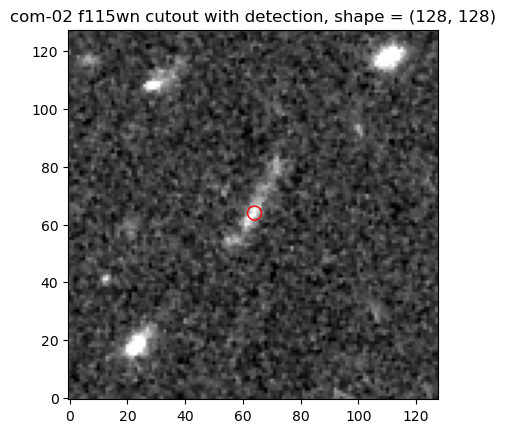

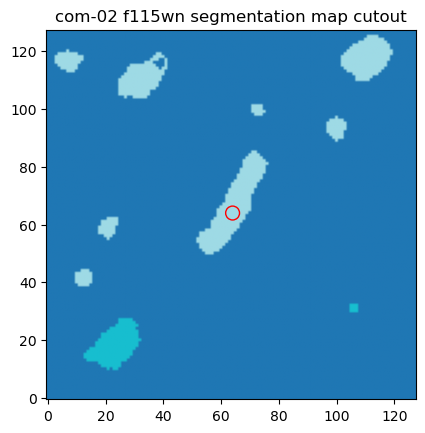

Image data units: 10.0*nanoJansky pixel scale: (39.999999999999595, 39.99999999999996)
Empty pixels fraction in cutout: 0.00%


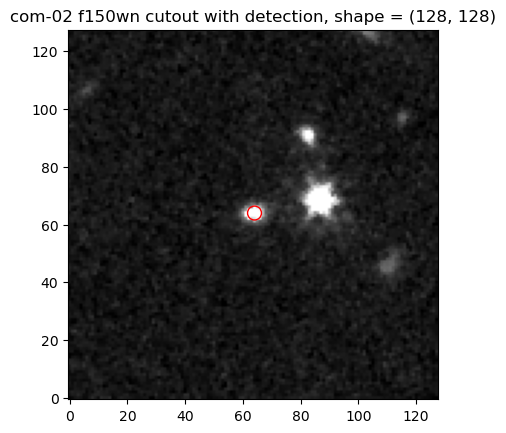

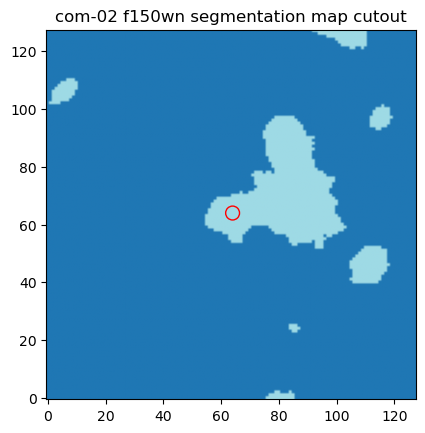

Image data units: 10.0*nanoJansky pixel scale: (39.999999999999595, 39.99999999999996)
Empty pixels fraction in cutout: 0.00%


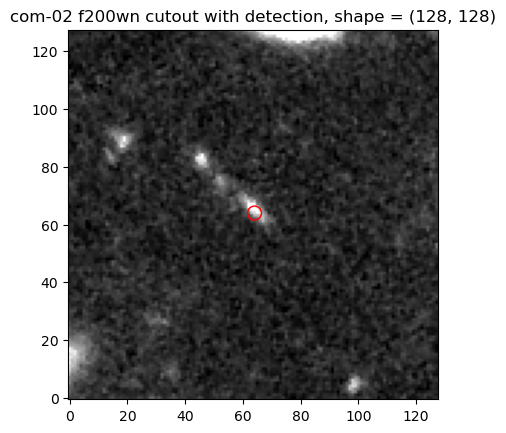

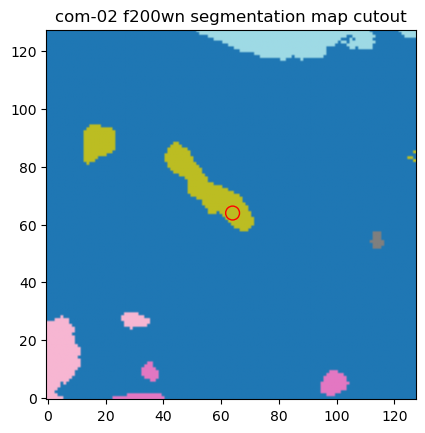

In [9]:
for field in fields[30:31]:
    #field = 'uma-03'
    for filt in filters:
        path = f"imaging/{field}/{field}-{filt}-clear_drc_sci.fits"
        if os.path.exists(path):
            with fits.open(path) as hdul:
                data = hdul[0].data
                #print units
                #comute pixel scale from CD1_1 and CD2_2
                cd1_1 = hdul[0].header.get("CD1_1", 0)
                cd2_2 = hdul[0].header.get("CD2_2", 0)
                pixel_scale_x = abs(cd1_1) * 3600 * 1000  # arcsec/pixel->mas
                pixel_scale_y = abs(cd2_2) * 3600 * 1000  # arcsec/pixel->mas
                pixel_scale = (pixel_scale_x, pixel_scale_y)
                print("Image data units:", hdul[0].header.get("BUNIT", "unknown"), "pixel scale:", pixel_scale)
                detection = Table.read(f"imaging/{field}/{field}-ir.cat.fits")
                fit_results = Table.read(f"imaging/{field}/{field}_fitresults.fits")
                #visualize one random image cutout with detections
                index = np.random.randint(len(fit_results))
                ra, dec = fit_results['ra'][index], fit_results['dec'][index]
                #convert from ra, dec to pixel coordinates
                wcs = WCS(hdul[0].header)
                x, y = wcs.world_to_pixel_values(ra, dec)
                x, y = int(x), int(y)
                size = 128
                cutout = data[y-size//2:y+size//2, x-size//2:x+size//2]
                #if empty pixels frac > 0.5
                empty_frac = np.mean(cutout == 0)
                print(f"Empty pixels fraction in cutout: {empty_frac:.2%}")

                vmin, vmax = np.percentile(cutout, [0.5, 99.5])
                plt.imshow(cutout, origin='lower', cmap='gray', vmin=vmin, vmax=vmax)
                plt.scatter(size//2, size//2, s=100, edgecolor='red', facecolor='none')
                plt.title(f"{field} {filt} cutout with detection, shape = {cutout.shape}")
                plt.show()
                
                #checkout the segmentation map for the same location
                seg_path = f"imaging/{field}/{field}-ir_seg.fits"
                if os.path.exists(seg_path):
                    with fits.open(seg_path) as seg_hdul:
                        seg_data = seg_hdul[0].data
                        seg_cutout = seg_data[y-size//2:y+size//2, x-size//2:x+size//2]
                        plt.imshow(seg_cutout, origin='lower', cmap='tab20')
                        plt.scatter(size//2, size//2, s=100, edgecolor='red', facecolor='none')
                        plt.title(f"{field} {filt} segmentation map cutout")
                        plt.show()
                spectra_fitting = Table.read(f"imaging/{field}/{field}_fitresults.fits")
                detection = Table.read(f"imaging/{field}/{field}-ir.cat.fits")
                
                

In [7]:
num_fit_results = 0
num_detections = 0
for field in fields:
    try:
        spectra_fitting = Table.read(f"imaging/{field}/{field}_fitresults.fits")
        detection = Table.read(f"imaging/{field}/{field}-ir.cat.fits")
        num_fit_results += len(spectra_fitting)
        num_detections += len(detection)
        print(field)
        print(len(spectra_fitting), "fit results,", len(detection), "detections")
    except Exception as e:
        print(f"Error occurred while processing {field}: {e}")
print(f"Total fit results: {num_fit_results}, total detections: {num_detections}")
print(f'Total detections: {num_detections}, total fit results: {num_fit_results}, average fit results per detection: {num_fit_results/num_detections:.2f}')

aqr-00
557 fit results, 1596 detections
aqr-01
434 fit results, 1716 detections
aqr-02
477 fit results, 2119 detections
boo-00
1053 fit results, 1597 detections
boo-01
569 fit results, 2499 detections
boo-02
670 fit results, 2628 detections
boo-03
1771 fit results, 2164 detections
boo-04
1051 fit results, 4208 detections
boo-05
3761 fit results, 14110 detections
boo-06
974 fit results, 3590 detections
boo-07
725 fit results, 3050 detections
boo-08
664 fit results, 2905 detections
boo-09
922 fit results, 3382 detections
boo-10
470 fit results, 2037 detections
boo-11
401 fit results, 2605 detections
cam-00
645 fit results, 3148 detections
cet-00
563 fit results, 2485 detections
cet-01
633 fit results, 2536 detections
cet-02
512 fit results, 2413 detections
cet-03
609 fit results, 2482 detections
cet-04
782 fit results, 2869 detections
cet-05
2756 fit results, 5537 detections
cet-06
2179 fit results, 4586 detections
cet-07
693 fit results, 1975 detections
cet-08
583 fit results, 2507 dete